# Checking files

In [1]:
import xarray as xr
import numpy as np
import geopandas as gpd
import regionmask

### Check downloaded ERA5-Land and NN-interpolated ERA5 data

In [ ]:
# check ERA5-Land files
era5_land_2000_01 = xr.open_dataset('era5_land_data/era5_land_2000_01.nc') # open ERA5-Land NetCDF file
print(era5_land_2000_01)
print("\nresolution: ", abs(era5_land_2000_01['d2m'].latitude[1] - era5_land_2000_01['d2m'].latitude[0]).values)

In [7]:
# check NN-interpolated ERA5 files
era5_2000_01_nn = xr.open_dataset('era5_interpolated/era5_2000_01_nn.nc') # open ERA5 NN-interpolated file
print(era5_2000_01_nn) # view structure

print("\nresolution: ", abs(era5_2000_01_nn['fdir'].latitude[1] - era5_2000_01_nn['fdir'].latitude[0]).values)
print("interpolated ERA5 fdir long name: ", era5_2000_01_nn["fdir"].attrs["long_name"], 
      "\ninterpolated ERA5 fdir units: ", era5_2000_01_nn["fdir"].attrs["units"])

<xarray.Dataset> Size: 60MB
Dimensions:     (valid_time: 744, latitude: 96, longitude: 105)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2000-01-01 ... 2000-01-31T23:...
  * latitude    (latitude) float64 768B 42.0 41.9 41.8 41.7 ... 32.7 32.6 32.5
  * longitude   (longitude) float64 840B -124.5 -124.4 -124.3 ... -114.2 -114.1
    number      int64 8B ...
    expver      (valid_time) <U4 12kB ...
Data variables:
    fdir        (valid_time, latitude, longitude) float32 30MB ...
    ssrd        (valid_time, latitude, longitude) float32 30MB ...
Attributes:
    source:         ERA5
    target_grid:    target_tif.tif
    interpolation:  Nearest-neighbor in lon/lat space (Spangler-style)
    crs:            EPSG:4326

resolution:  0.10000000000000142
interpolated ERA5 fdir long name:  ERA5 fdir (nearest-neighbor interpolated) 
interpolated ERA5 fdir units:  J m**-2


### View values of preprocessed variables -- plotting variables at a single valid_time

In [2]:
wbgt_inputs_2000_01 = xr.open_dataset('wbgt_inputs_2000_01.nc') # open inputs part 1 file
print(wbgt_inputs_2000_01)

<xarray.Dataset> Size: 240MB
Dimensions:     (valid_time: 744, latitude: 96, longitude: 105)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2000-01-01 ... 2000-01-31T23:...
  * latitude    (latitude) float64 768B 42.0 41.9 41.8 41.7 ... 32.7 32.6 32.5
  * longitude   (longitude) float64 840B -124.5 -124.4 -124.3 ... -114.2 -114.1
    number      int64 8B ...
    expver      (valid_time) <U4 12kB ...
    year        (valid_time) int64 6kB ...
    month       (valid_time) int64 6kB ...
    day         (valid_time) int64 6kB ...
    hour        (valid_time) int64 6kB ...
    dday        (valid_time) float64 6kB ...
Data variables:
    ssrd_W      (valid_time, latitude, longitude) float32 30MB ...
    fdir_frac   (valid_time, latitude, longitude) float32 30MB ...
    pres        (valid_time, latitude, longitude) float32 30MB ...
    Tair        (valid_time, latitude, longitude) float32 30MB ...
    relhum      (valid_time, latitude, longitude) float32 30MB ...
    speed      

In [4]:
ca = gpd.read_file("deriving urban/ca_grid/ERA5_Land_grid_CAfull.shp")
ca = ca.to_crs("EPSG:4326")
mask = regionmask.mask_geopandas(ca, wbgt_inputs_2000_01.longitude, wbgt_inputs_2000_01.latitude)

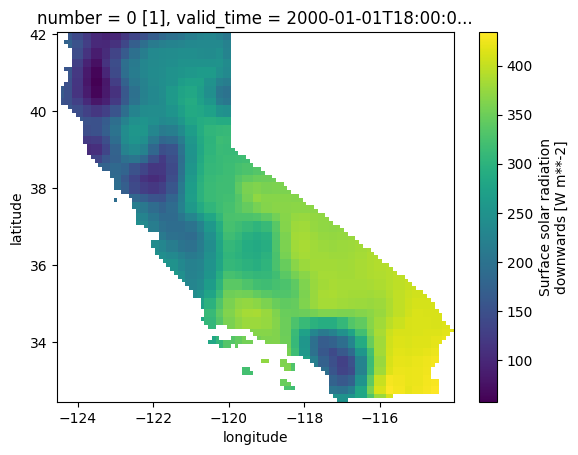

In [5]:
wbgt_inputs_2000_01["ssrd_W"].where(~mask.isnull()).sel(valid_time="2000-01-01T18:00").plot(cmap="viridis")

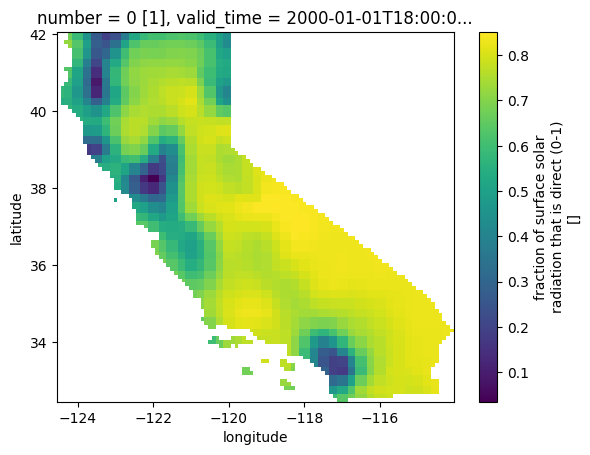

In [6]:
wbgt_inputs_2000_01["fdir_frac"].where(~mask.isnull()).sel(valid_time="2000-01-01T18:00").plot(cmap="viridis")

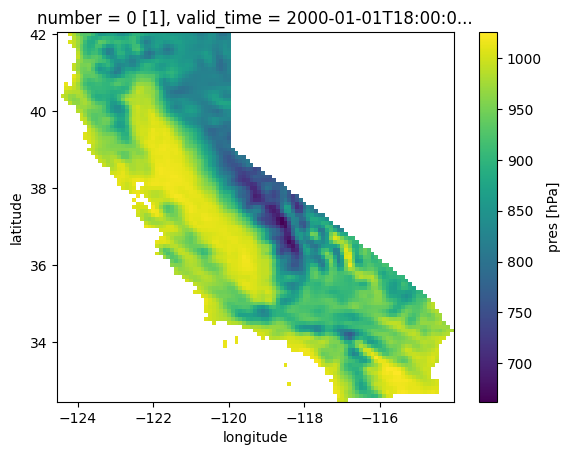

In [10]:
wbgt_inputs_2000_01["pres"].where(~mask.isnull()).sel(valid_time="2000-01-01T18:00").plot(cmap="viridis")

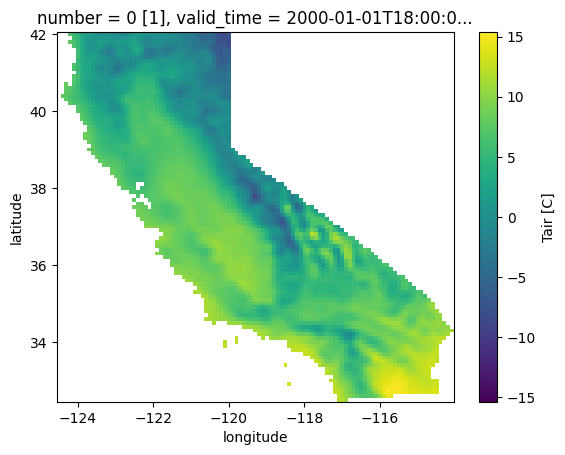

In [11]:
wbgt_inputs_2000_01["Tair"].where(~mask.isnull()).sel(valid_time="2000-01-01T18:00").plot(cmap="viridis")

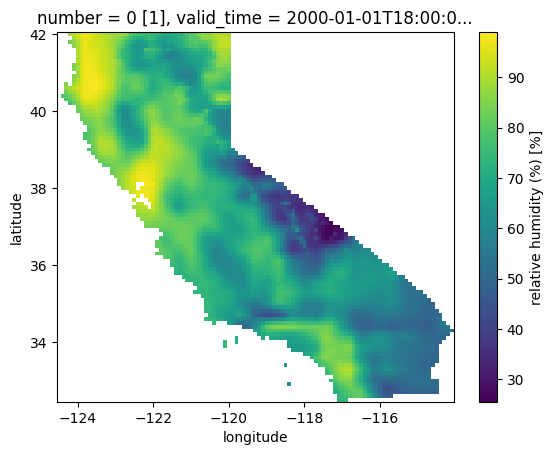

In [9]:
wbgt_inputs_2000_01["relhum"].where(~mask.isnull()).sel(valid_time="2000-01-01T18:00").plot(cmap="viridis")

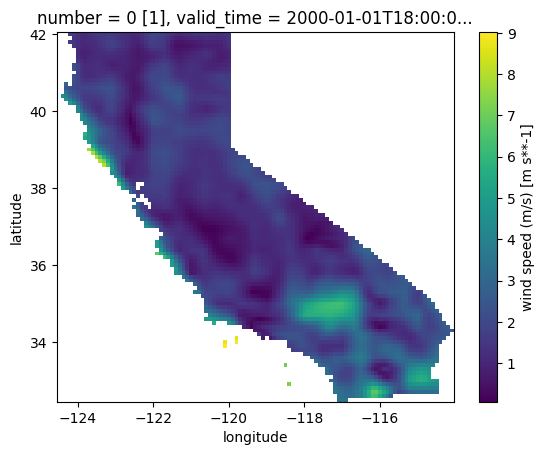

In [12]:
wbgt_inputs_2000_01["speed"].where(~mask.isnull()).sel(valid_time="2000-01-01T18:00").plot(cmap="viridis")

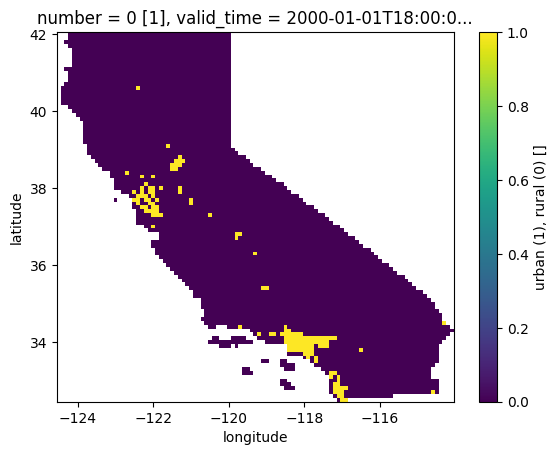

In [13]:
wbgt_inputs_2000_01["urban"].where(~mask.isnull()).sel(valid_time="2000-01-01T18:00").plot(cmap="viridis")